<!-- COLAB-BADGE -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB11_Cybersecurity.ipynb)  
[Download .ipynb](https://raw.githubusercontent.com/brendanpshea/computing_concepts_python/main/v2/notebooks/COMP1150_NB11_Cybersecurity.ipynb) · [View on GitHub](https://github.com/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB11_Cybersecurity.ipynb)


# Notebook 11: Cybersecurity — Defending the Clinic
### COMP 1150 — Computer Science Concepts
**Brendan Shea, PhD**

<!-- Lecture video link to be added -->
📺 **Lecture video:** *(coming soon)*

## Learning Outcomes

By the end of this notebook, you will be able to:

- Use the CIA triad — confidentiality, integrity, availability — to reason about what a system must protect
- Explain how SQL injection works, and stop it with parameterized queries
- Describe cross-site scripting and the general rule of never trusting user input
- Distinguish hashing from encryption, and store passwords safely with salting
- Keep secrets like API keys out of your code and out of your git history

*Maps to course LOs: 12*

## The Clinic That Leaked

At 6 a.m., **Mina Harker's** phone rings. Mina is chief risk officer at Harker Risk & Insurance, and the caller is **Victor Frankenstein**, CTO of Frankenstein BioLab. His clinic's patient portal — a small web app, the kind a student could build in a weekend — has just leaked forty thousand medical records.

There was no break-in. No door was forced. The building alarms never went off. Someone simply typed the right thing into the wrong box on the login page, and the app handed over its entire database.

Mina has seen this a hundred times. "Victor," she says, pulling on her coat, "your app has doors you never counted. Attackers don't pick locks. They walk through the doors you forgot were there."

This is the notebook where your programs grow enemies.

In the last notebook you built a web server and opened it to the network — where *anyone* can send it a request. Most are ordinary visitors. A few are not. This notebook is about that few: the attacks that target a small web app like the one you'll build for your final project, and the defenses that stop them.

Mina's method is the whole plan. She doesn't guess where the danger is. She **enumerates every door and tests each one**:

1. **What are we even protecting?** The three questions behind every security decision.
2. **The open door** — SQL injection, the attack that leaked Victor's records.
3. **Poisoned input** — why *all* user input is a threat, and cross-site scripting.
4. **The locked door** — hashing, salting, and how to store passwords safely.
5. **The key under the mat** — secrets like passwords and API keys, and how to not leak them.

At the end, you'll run a real security audit: take a deliberately broken app and harden it, door by door.

## 1. What Are We Protecting? The CIA Triad

Before you can defend a system, you have to know what "safe" even means for it. Security professionals answer that with three questions, known as the **CIA triad** — nothing to do with the agency, everything to do with three properties every system needs:

- **Confidentiality** — can the *wrong people read* the data? (Victor's leak was a confidentiality failure: outsiders read patient records.)
- **Integrity** — can the wrong people *change* the data? (Imagine an attacker altering a prescription's dosage.)
- **Availability** — can they *stop the system working* at all? (Imagine the portal knocked offline so no doctor can reach any record.)

Every attack in this notebook breaks at least one of these. Every defense protects at least one. When Mina audits a system, she walks every asset past all three questions.

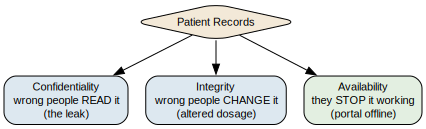

In [1]:
#| label: fig-cia
import graphviz
graphviz.Source(r"""digraph G {
  bgcolor="transparent"; rankdir=TB;
  node [shape=box, style="rounded,filled", fontname="Helvetica", fontsize=11];
  triad [label="Patient Records", shape=diamond, fillcolor="#f3e9d8"];
  c [label="Confidentiality\nwrong people READ it\n(the leak)", fillcolor="#dde8f0"];
  i [label="Integrity\nwrong people CHANGE it\n(altered dosage)", fillcolor="#dde8f0"];
  a [label="Availability\nthey STOP it working\n(portal offline)", fillcolor="#e3efe1"];
  triad -> c; triad -> i; triad -> a;
}""")

**Reading it:** one asset — the patient records — faces three distinct dangers. A defense that guarantees confidentiality (say, hiding the data) does nothing for availability (the data can still be knocked offline). That's why security is never one lock. It's a checklist you run on everything valuable.

### Modeling Threats as Data

Mina doesn't keep this in her head — she writes it down. A **threat model** is just a list of "what could go wrong," and it's ordinary data you already know how to handle: a list of dictionaries, one per threat.

The next cell is the start of Mina's threat model for the clinic. Each entry names an asset, the threat to it, and which CIA property it breaks.

In [2]:
threat_model = [
    {"asset": "patient records", "threat": "leaked via login box", "breaks": "confidentiality"},
    {"asset": "prescriptions",   "threat": "dosage altered",       "breaks": "integrity"},
    {"asset": "the portal",      "threat": "flooded offline",      "breaks": "availability"},
]

for row in threat_model:
    print(f"{row['breaks']:16} <- {row['asset']} ({row['threat']})")

confidentiality  <- patient records (leaked via login box)
integrity        <- prescriptions (dosage altered)
availability     <- the portal (flooded offline)


That's the whole discipline in one loop: enumerate what you have, name what could happen to it, label the property at risk. A messy list like this, written *before* you're attacked, is worth more than any single clever defense. It turns "are we secure?" — a question no one can answer — into "have we handled every row?" — a question you can.

### 💭 Think About It — Which Letter Matters Most?

The three properties aren't equally important for every system. Rank C, I, and A for each of these, and be ready to defend your order:

- a hospital's patient records
- a bank's account balances
- a public group chat for planning a birthday party

There's no single right ranking — that's the point. Security starts with knowing what *you* most cannot afford to lose.

## 2. The Open Door: SQL Injection

Now the attack that leaked Victor's clinic. It's called **SQL injection**, and it's been near the top of every "most dangerous vulnerabilities" list for twenty years. To see it, we need to look at how Victor's login worked.

When someone logs in, the app takes the username they typed and builds a database query to look them up. Victor's code built that query the tempting, disastrous way: by gluing the user's text directly into the SQL string.

The next cell sets up a tiny version of Victor's user database, so we can watch the attack happen safely.

In [3]:
import sqlite3

db = sqlite3.connect(":memory:")
db.execute("CREATE TABLE users (name TEXT, role TEXT)")
db.executemany("INSERT INTO users VALUES (?, ?)",
               [("mina", "admin"), ("victor", "doctor"), ("igor", "clerk")])
db.commit()
print("Set up 3 users.")

Set up 3 users.


Here is Victor's mistake — the vulnerable lookup. It builds the query by pasting the username straight into the SQL text with an f-string. For a normal username like `mina`, it works perfectly, which is exactly why the bug survives to production.

In [4]:
def unsafe_login(username):
    query = f"SELECT * FROM users WHERE name = '{username}'"
    print("QUERY:", query)
    return db.execute(query).fetchall()

print(unsafe_login("mina"))

QUERY: SELECT * FROM users WHERE name = 'mina'
[('mina', 'admin')]


Normal input, normal result: one row for `mina`. The query reads `... WHERE name = 'mina'`. Nothing looks wrong.

Now the attacker. Instead of a username, they type this into the login box:

```
' OR '1'='1
```

### 🔮 Predict Before You Run

Look at how `unsafe_login` builds its string. When the username is `' OR '1'='1`, what will the finished `QUERY` line actually say? And `'1'='1'` is *always* true — so how many rows will come back? Write down your guess, then run the next cell.

In [5]:
attack = "' OR '1'='1"
print(unsafe_login(attack))

QUERY: SELECT * FROM users WHERE name = '' OR '1'='1'
[('mina', 'admin'), ('victor', 'doctor'), ('igor', 'clerk')]


### Understanding the Attack

The finished query became:

```
SELECT * FROM users WHERE name = '' OR '1'='1'
```

The attacker's quote mark closed Victor's string early, and their `OR '1'='1'` bolted on a condition that is *always true*. So the database happily returned **every user** — Mina, Victor, and Igor. Scale that from three rows to forty thousand patients, and you have Victor's morning.

The root cause has a name worth remembering: **the data became code.** The app meant the username to be *data* — a value to look up. But because it was pasted into the query text, a cleverly written username turned into *commands* the database obeyed. Every injection attack, of every kind, is a version of this one confusion.

### The Fix: Parameterized Queries

The fix is not to hunt for bad characters or ban apostrophes. It's to *never let data into the code position in the first place.* You do this with a **parameterized query**: leave a `?` placeholder in the SQL, and hand the value to the database *separately*. The database then treats it as pure data — never as commands, no matter what's in it.

Watch the same attack hit the safe version.

In [6]:
def safe_login(username):
    return db.execute("SELECT * FROM users WHERE name = ?", (username,)).fetchall()

print("normal:", safe_login("mina"))
print("attack:", safe_login("' OR '1'='1"))

normal: [('mina', 'admin')]
attack: []


### Understanding the Fix

- The `?` is a placeholder. The real value rides in the second argument, the tuple `(username,)`.
- The database keeps the query and the value in separate hands. The username `' OR '1'='1` is now looked up as a *literal name* — and since no user is actually called that, the attack returns an empty list.
- Normal logins still work exactly as before.

This is the entire defense, and it's less code than the broken version. The rule for the rest of your life as a programmer: **never build a SQL query by gluing in user input. Always use `?` placeholders.** Your database library — the `sqlite3` you already know — has supported this the whole time.

### ✏️ Your Turn — Close Victor's Other Door

Victor has a second vulnerable function: `find_role`, which looks up a user's role. It's built the unsafe way. Rewrite it to use a parameterized query, then confirm the attack string returns nothing.

In [7]:
#| eval: false
# ⬇️ This is the VULNERABLE version. Fix it.
def find_role(username):
    query = f"SELECT role FROM users WHERE name = '{username}'"
    return db.execute(query).fetchall()

# TODO: rewrite find_role to use a ? placeholder.
# Then test it:
# print(find_role("mina"))                 # should find the admin
# print(find_role("' OR '1'='1"))          # should return []

## 3. Poisoned Input: Never Trust the User

SQL injection is one case of a much larger law, and **Abraham Van Helsing** — who has spent his career hunting things that hide inside ordinary-looking bodies — states it plainly: *"All input is a suspect until proven innocent."*

Any data that comes from *outside* your program — a form field, a URL, an uploaded file, a response from another server — could have been crafted by an attacker. SQL injection poisons a database query. Its cousin poisons a *web page*.

### Cross-Site Scripting (XSS)

Suppose the clinic portal lets patients leave a comment, and later shows those comments to staff. A normal patient writes "Running five minutes late." An attacker writes this:

```
<script>steal_the_session()</script>
```

If the portal drops that text straight onto the page, the victim's browser can't tell the attacker's `<script>` from the site's own code — so it *runs it*. That's **cross-site scripting**, or XSS: input that becomes executable code in someone else's browser. Same root cause as before — data became code — just aimed at the page instead of the database.

### The Defense: Escaping

The fix is to turn dangerous characters into harmless display text *before* showing them — a step called **escaping** (or sanitizing). The `<` that starts a tag becomes `&lt;`, which a browser *shows* as a literal "<" instead of *obeying* as the start of a script.

The next cell shows the transformation with Python's built-in `html.escape`.

In [8]:
import html

attacker_comment = "<script>steal_the_session()</script>"
print("stored raw:   ", attacker_comment)
print("escaped safe: ", html.escape(attacker_comment))

stored raw:    <script>steal_the_session()</script>
escaped safe:  &lt;script&gt;steal_the_session()&lt;/script&gt;


The escaped version displays as text and does nothing. Here is the reassuring part: the template tool Flask uses (Jinja) does this escaping **automatically** for every value you drop into a page. Much of your XSS defense is handled for you — as long as you don't go out of your way to disable it. The danger returns the moment you mark something "safe" to skip escaping, which is why you should almost never do that.

### Validation: Checking Input Before You Trust It

Escaping handles output. The other half of Van Helsing's law is **input validation**: before you accept a value, check that it's the *shape* you expected — right type, sane length, allowed characters. A field asking for an age should reject `"; DROP TABLE"` for the simple reason that it isn't a number.

The next cell is a small validator for the clinic's intake form.

In [9]:
def validate_age(raw):
    if not raw.isdigit():
        return False, "Age must be digits only."
    age = int(raw)
    if age < 0 or age > 120:
        return False, "Age must be between 0 and 120."
    return True, age

for test in ["37", "-4", "200", "'; DROP TABLE users; --"]:
    print(f"{test!r:28} -> {validate_age(test)}")

'37'                         -> (True, 37)
'-4'                         -> (False, 'Age must be digits only.')
'200'                        -> (False, 'Age must be between 0 and 120.')
"'; DROP TABLE users; --"    -> (False, 'Age must be digits only.')


Only the sensible value survives. Validation won't catch every attack on its own — you still use parameterized queries and escaping — but it's the first gate, and it turns away the crudest attacks before they get anywhere.

*(A related attack, **cross-site request forgery** (CSRF), tricks a logged-in user's browser into sending a request they never intended — like a hidden button that transfers money using their active session. Full web frameworks including Flask ship with built-in CSRF protection you switch on; it's worth knowing the name exists.)*

### ✏️ Your Turn — Van Helsing's Filter

The clinic wants a validator for a patient's phone number: it must be **exactly 10 digits**, nothing else. Write `validate_phone(raw)` that returns `True` for `"5075551234"` and `False` for a number that's too short, has letters, or contains a `<script>` tag.

In [10]:
#| eval: false
def validate_phone(raw):
    # TODO: return True only for exactly 10 digits.
    pass

# for test in ["5075551234", "123", "abcd", "<script>", "507-555-1234"]:
#     print(test, "->", validate_phone(test))

## 4. The Locked Door: Passwords, Hashing & Salting

**Christine Daaé** runs a talent agency, and she has a stalker — someone who tries to log into her account night after night, guessing password after password. Her problem raises the deepest question in this notebook: how should a system store passwords at all?

The naive answer — keep a list of everyone's password — is a catastrophe waiting for one leak. If Victor's database had stored passwords as plain text, the attacker wouldn't just have this year's records; they'd have passwords that people reuse on their bank, their email, everywhere. **A system should never be able to read its own users' passwords.**

That sounds impossible — how do you check a password you can't read? The answer is one of the most elegant ideas in computing.

### Hashing vs. Encryption

Two tools are easy to confuse:

- **Encryption** is a *two-way* lock. You scramble data with a key, and anyone with the key can unscramble it back. Use it for data you need to *read again later* — a message in transit, a file at rest.
- **Hashing** is a *one-way* lock. It turns any input into a fixed-length fingerprint, and there is **no way back** — you cannot un-hash a fingerprint to recover the input. Use it for passwords, exactly *because* you never want to recover them.

The trick for passwords: store the *hash*, never the password. When a user logs in, hash what they typed and compare the two fingerprints. Same password always makes the same fingerprint, so the check works — but a stolen database yields only fingerprints, not passwords.

The next cell hashes a password with `hashlib` (the same family of tools that fingerprints files and secures the web).

In [11]:
import hashlib

def sha(text):
    return hashlib.sha256(text.encode()).hexdigest()

print("hunter2      ->", sha("hunter2"))
print("hunter2 again->", sha("hunter2"))
print("hunter3      ->", sha("hunter3"))

hunter2      -> f52fbd32b2b3b86ff88ef6c490628285f482af15ddcb29541f94bcf526a3f6c7
hunter2 again-> f52fbd32b2b3b86ff88ef6c490628285f482af15ddcb29541f94bcf526a3f6c7
hunter3      -> fb8c2e2b85ca81eb4350199faddd983cb26af3064614e737ea9f479621cfa57a


Two things to notice. The same password gives the *same* fingerprint every time — that's what lets you verify a login. And a one-character change gives a *completely different* fingerprint — so the stored value tells an attacker nothing about how close a guess was.

But there's a crack in this door, and Christine's stalker knows it.

### Why Plain Hashing Isn't Enough: Salting

Look again: `hunter2` *always* hashes to the same value. So two users with the same password store the *identical* fingerprint — and attackers have precomputed giant tables of "fingerprint → common password" (called rainbow tables). If your password is common, its hash is already in a lookup table somewhere.

The fix is a **salt**: a chunk of random data, different for every user, mixed into the password before hashing. Now two users with the same password get *different* fingerprints, and the attacker's precomputed tables are worthless — they'd need a fresh table for every salt.

The next cell shows two users, both with the password `hunter2`, ending up with different stored hashes.

In [12]:
import hashlib, os

def hash_with_salt(password, salt):
    return hashlib.sha256(salt + password.encode()).hexdigest()

alice_salt = os.urandom(8)      # 8 random bytes, unique to Alice
bob_salt   = os.urandom(8)      # a different 8 for Bob

print("Alice:", hash_with_salt("hunter2", alice_salt))
print("Bob:  ", hash_with_salt("hunter2", bob_salt))

Alice: d6f863ffd64a12fabda2f9ecf6874e1f1edbbc48e70baa573600d654158dc5e6
Bob:   7f4f8aa3251610807bc149e033544b9bc3f1ab1e7d2819576dbf10ead47196e3


Same password, two different stored fingerprints — because each was salted differently. You store the salt alongside the hash (it isn't secret); its job is only to make every user's hash unique and defeat precomputed tables.

One last, crucial rule. **Don't actually build this yourself.** Real password storage also needs the hashing to be deliberately *slow*, to blunt the stalker who guesses millions of times per second. Battle-tested tools do salting and slowness for you — `bcrypt`, or the `werkzeug.security` functions that come with Flask. The lesson here is to *understand* what they do, so you'll recognize when they're missing. The code you should ship is:

```
from werkzeug.security import generate_password_hash, check_password_hash

stored = generate_password_hash("hunter2")     # salted + slow, automatically
check_password_hash(stored, "hunter2")         # True
```

Christine's stalker, meanwhile, is a **brute-force** attack: try every guess until one works. Slow hashing makes each guess costly, and a simple rule — lock the account after several failures — turns "millions of guesses a second" into "five guesses an hour." Availability defended, without ever storing a readable password.

### ✏️ Your Turn — Verify a Login

Write `check_login(stored_hash, salt, attempt)` that hashes the `attempt` with the given `salt` and returns `True` only if it matches `stored_hash`. Use it to confirm that `"hunter2"` logs in and `"password123"` does not.

In [13]:
#| eval: false
import hashlib

def check_login(stored_hash, salt, attempt):
    # TODO: hash the attempt with the salt, compare to stored_hash, return True/False.
    pass

# salt = os.urandom(8)
# stored = hashlib.sha256(salt + b"hunter2").hexdigest()
# print(check_login(stored, salt, "hunter2"))       # True
# print(check_login(stored, salt, "password123"))   # False

## 5. The Locked Hallway: Encryption in Transit (HTTPS)

So far we've protected data sitting *inside* the app — the database, the stored passwords. But a patient logging in from a coffee shop sends their password across a stranger's Wi-Fi, then through an internet provider, then across routers owned by companies they've never heard of. Their data is most exposed not at rest, but *on the journey*.

This is a new place for confidentiality to fail, and it has nothing to do with your code's logic. Recall how data crosses a network: chopped into packets that hop from machine to machine. Anyone sitting on that path — the café's router, the provider, someone running a snooping tool on the same Wi-Fi — can read every packet that passes. If the login travels as plain, readable text, they read the password.

Plain **HTTP** sends everything as readable text. That's the danger.

### The Fix: HTTPS

**HTTPS** is simply HTTP with **encryption** added — the *S* stands for *secure*. Remember encryption from the last section: the two-way lock, where data is scrambled with a key and only the holder can unscramble it. HTTPS wraps the entire conversation between browser and server in that lock. An eavesdropper on the path still sees the packets go by — but all they see is scrambled gibberish. Only the browser and the clinic's server hold the key to read it.

That is exactly what the **padlock icon** in your browser's address bar means: this connection is encrypted, so no one in between can read it.

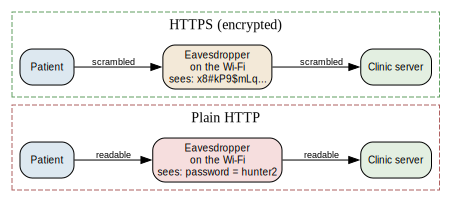

In [14]:
#| label: fig-https
import graphviz
graphviz.Source(r"""digraph G {
  bgcolor="transparent"; rankdir=LR;
  node [shape=box, style="rounded,filled", fontname="Helvetica", fontsize=10];
  edge [fontname="Helvetica", fontsize=9];

  subgraph cluster_http {
    label="Plain HTTP"; style=dashed; color="#b06060";
    p1 [label="Patient", fillcolor="#dde8f0"];
    e1 [label="Eavesdropper\non the Wi-Fi\nsees: password = hunter2", fillcolor="#f6dede"];
    s1 [label="Clinic server", fillcolor="#e3efe1"];
    p1 -> e1 -> s1 [label="readable"];
  }
  subgraph cluster_https {
    label="HTTPS (encrypted)"; style=dashed; color="#60a060";
    p2 [label="Patient", fillcolor="#dde8f0"];
    e2 [label="Eavesdropper\non the Wi-Fi\nsees: x8#kP9$mLq...", fillcolor="#f3e9d8"];
    s2 [label="Clinic server", fillcolor="#e3efe1"];
    p2 -> e2 -> s2 [label="scrambled"];
  }
}""")

**Reading it:** the data travels the same path both ways, past the same eavesdropper. Over plain HTTP the password is readable in transit; over HTTPS it's scrambled, and the snooper on the café Wi-Fi gets nothing useful.

HTTPS quietly does one more job: it proves the server *is who it claims to be*. A trusted outside authority issues the clinic a **certificate** vouching for its identity, so your browser can tell the real clinic from an impostor site pretending to be it. That's why a browser warns you loudly about a "certificate error" — it can no longer confirm who's on the other end.

The practical rule for your own projects is short: **never send passwords or personal data over plain HTTP.** The good news is you rarely set this up by hand. The hosting platforms you might deploy to provide HTTPS automatically, and the tunneling tool used to share a Colab app gives you an HTTPS address for free. Your job is mostly to *use* it — and to never wave away a certificate warning.

### 💭 Think About It — What the Padlock Really Promises

Many people were taught "look for the padlock, then the site is safe." But scam sites can get a padlock too — certificates are easy to obtain.

So what does the padlock *actually* guarantee? And what does it say nothing about? Why might "this connection is private" and "this site is trustworthy" be two very different claims?

## 6. The Key Under the Mat: Secrets Management

**Jonathan Harker**, a lawyer, made the most common security mistake in the world, and it wasn't clever at all. Building a small app, he typed his email service's password directly into his code so it would work:

```
API_KEY = "sk_live_9f8a7b6c5d4e3f2a1b"   # <- right there in the file
```

Then he pushed the code to GitHub. Within hours, bots that constantly scan public repositories for exactly this found the key and ran up a bill. A **secret** — a password, an API key, a database credential — is anything that grants access, and the rule is absolute: **secrets never go in your code.**

### The Fix: Environment Variables

Instead of writing the secret in the file, you store it *outside* the code — in an **environment variable**, a value the operating system holds — and your program reads it at runtime. The code contains only the *name* of the secret, never the secret itself.

In [15]:
import os

# The code names the secret but never contains it.
api_key = os.environ.get("CLINIC_API_KEY", "(not set)")

print("Key loaded from environment:", api_key)

Key loaded from environment: (not set)


The code above is safe to share with the world — there's no secret in it, only a request to read one named `CLINIC_API_KEY`. You set the actual value separately: on your own machine, in the operating system; on Colab, using the **Secrets** panel (the 🔑 icon in the left sidebar), read with `google.colab.userdata.get("CLINIC_API_KEY")`. Either way, the secret never touches a file you might share.

You also tell git to ignore the files that *do* hold secrets locally (like a `.env` file) by listing them in a special file named **`.gitignore`**. Git then refuses to track them, so they can't be committed by accident.

### 💭 Think About It — Jonathan's "Fix"

Jonathan realizes his mistake. In his *next* commit, he deletes the key from the file and pushes again. The current version of his code is clean. He relaxes.

He shouldn't. Why is the key *still* exposed, even though it's gone from the latest version? (Think about what a version-control system keeps, and never forgets.) What does Jonathan actually have to do to be safe?

## 7. Layers on Layers: Defense in Depth

Step back and look at what you've built. You have not learned *one* way to secure an app — you've learned six, and that plurality is the whole point.

Victor's clinic wasn't breached because he was missing a single clever defense. It was breached because one weak spot — the login box — had *nothing behind it*. One failure was all it took. The professional answer to that is a principle called **defense in depth**: stack multiple independent defenses so that no single failure exposes everything. Assume any one layer *will* eventually fail, and make sure another one is waiting behind it.

A castle is the old image: not one wall, but a moat, an outer wall, a gate, and guards. An attacker who swims the moat still faces the wall. For the clinic's login form, your layers stack the same way.

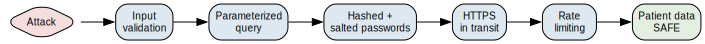

In [16]:
#| label: fig-defense
import graphviz
graphviz.Source(r"""digraph G {
  bgcolor="transparent"; rankdir=LR;
  node [shape=box, style="rounded,filled", fontname="Helvetica", fontsize=10,
        fillcolor="#dde8f0"];
  edge [fontname="Helvetica", fontsize=9];
  atk [label="Attack", shape=diamond, fillcolor="#f6dede"];
  l1 [label="Input\nvalidation"];
  l2 [label="Parameterized\nquery"];
  l3 [label="Hashed +\nsalted passwords"];
  l4 [label="HTTPS\nin transit"];
  l5 [label="Rate\nlimiting"];
  win [label="Patient data\nSAFE", fillcolor="#e3efe1"];
  atk -> l1 -> l2 -> l3 -> l4 -> l5 -> win;
}""")

**Reading it:** an attack has to get past *every* layer to reach the data — and each layer stops a different kind of attack. Miss the validation? The parameterized query still blocks the injection. Database stolen anyway? The passwords are only salted hashes. Traffic sniffed? HTTPS scrambled it. Password guessing? Rate limiting locks them out. No layer is trusted to be perfect. That's what makes the stack strong.

This is why "are we secure?" is the wrong question, and "how many independent layers protect this?" is the right one. A single lock is a single point of failure — the very thing a network was designed to avoid, now applied to your app.

## ✏️ Capstone — The Security Audit

Every capstone so far has asked you to *build* something. This one asks you to *break and repair* something — the most valuable security skill there is.

Below is a description of a small, deliberately **insecure** clinic login app. Your job is Mina's job: find every door, and close it. You'll work with an AI assistant — but with a twist you now understand deeply: **AI will confidently write insecure code.** It was trained on millions of examples, many of them vulnerable. You are the auditor. You verify.

### Step 0 — Read the Broken App

Here is the vulnerable app's core logic (you don't run this — you audit it):

```python
@app.route("/login", methods=["POST"])
def login():
    name = request.form["username"]
    pw = request.form["password"]
    query = f"SELECT * FROM users WHERE name='{name}' AND password='{pw}'"
    user = db.execute(query).fetchall()
    return f"<h1>Welcome {name}</h1>" if user else "Denied"

API_KEY = "sk_live_realkey_do_not_share"
```

In the cell below, **list every vulnerability you can find** before asking any AI. Use the sections of this notebook as your checklist. There are at least four problems.

*(Double-click and write your audit findings here.)*

1.
2.
3.
4.

### Step 1 — Ask the AI to Find Them *(prompt #1)*

Now compare your list against an AI's. A prompt skeleton:

> Here is a Flask login route and a config line. Act as a security auditor.
> List every security vulnerability you find, and for each, name the specific fix.
> **[paste the broken code]**

Paste the AI's findings below. Did it catch everything you did? Did you catch anything *it* missed? (It happens — especially the leaked key and the missing password hashing.)

*(Paste and compare the AI's findings here.)*

### Step 2 — Fix It *(prompt #2)*

Ask the AI to rewrite the app securely. Then **verify each fix against what you learned** — don't just trust it:

- The login query uses a **`?` placeholder**, not an f-string.
- Passwords are checked with **`check_password_hash`**, never compared as plain text.
- The output escapes the username (or relies on a template that does).
- The **API key comes from `os.environ`**, not a string in the file.

Paste the AI's hardened version below, and annotate — in comments — which section of this notebook each fix comes from.

In [17]:
#| eval: false
# ✏️ Paste the AI's hardened app here. Add a comment on each fix naming
#    the vulnerability it closes (e.g. "# fixes SQL injection - section 2").

### Step 3 — Try to Break It, Then Reflect

Confirm the fixes actually work. On your hardened code, check:

1. Does the username `' OR '1'='1` still log you in? (It must not.)
2. Is there any readable password or key left anywhere in the file? (There must not be.)

Then reflect below, 2–3 sentences: What did the AI get wrong, or write insecurely, that you had to correct?

*AI is a fast first draft — and a fast first draft is often an insecure one. You verify.*

*(Your 2–3 sentence reflection — double-click to edit.)*

## Key Terms

- **.gitignore** — A file listing paths git should refuse to track, keeping secrets out of the repository.
- **Availability** — The security property that a system stays usable and reachable when needed.
- **Brute-force attack** — Trying every possible password or key until one works.
- **Certificate** — A credential from a trusted authority that vouches for a website's identity, letting HTTPS prove you're talking to the real server.
- **CIA triad** — Confidentiality, integrity, availability: the three properties security protects.
- **Confidentiality** — The security property that only authorized people can read the data.
- **CSRF (cross-site request forgery)** — Tricking a logged-in user's browser into sending a request they never intended.
- **Defense in depth** — Stacking multiple independent security layers so that no single failure exposes the whole system.
- **Encryption** — A reversible, two-way scrambling of data, unlockable with a key; for data you need to read back.
- **Environment variable** — A value stored outside your code, in the operating system, where a program can read a secret without containing it.
- **Escaping** — Converting dangerous characters into harmless display text to prevent input from running as code.
- **Hashing** — A one-way fingerprint of data that cannot be reversed; used to store passwords safely.
- **HTTPS** — HTTP with encryption added, so data in transit cannot be read by anyone on the network path.
- **Input validation** — Checking that incoming data has the expected type, length, and format before trusting it.
- **Integrity** — The security property that data cannot be changed by unauthorized people.
- **Parameterized query** — A SQL query using `?` placeholders so user input is treated as data, never as commands.
- **Plaintext** — Data sent or stored as readable text, with no encryption.
- **Salt** — Random data mixed into a password before hashing, unique per user, to defeat precomputed tables.
- **Secret** — Any credential (password, API key, database login) that grants access and must never appear in code.
- **SQL injection** — An attack that smuggles commands into a database query built from unsanitized user input.
- **Threat model** — A written list of a system's assets, the threats to each, and the properties at risk.
- **XSS (cross-site scripting)** — An attack where user input becomes executable code in another user's browser.


## Summary

Security is not one lock but a checklist run on everything you value. The CIA triad — confidentiality, integrity, availability — names what you're protecting. Nearly every attack in this notebook shares one root cause: *data became code.* SQL injection smuggles commands into a query, and parameterized `?` queries stop it; cross-site scripting smuggles scripts into a page, and escaping stops it. The rule underneath both is Van Helsing's: never trust input. Passwords demand a special tool — one-way hashing with a per-user salt, so a system can check a password it can never read — and battle-tested libraries, not homemade code, should do it. Finally, secrets like API keys belong outside your code and out of your git history, forever. None of this is exotic. It's a handful of habits that turn the doors you forgot about into doors you locked.

## What's Next

You've learned to defend the app. The final notebook turns to what happens *inside* it. As programs increasingly make decisions about people — who gets a loan, who gets flagged, who gets seen — the hardest questions stop being "is it secure?" and become "is it fair, and who is accountable when it isn't?" That's where we end: AI, machine learning, and ethics.

*COMP 1150 — Computer Science Concepts · Brendan Shea, PhD*
*Content licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*